In [361]:
import pandas as pd
import numpy as np
import sklearn as sk

In [362]:
from GENIE3 import *


In [363]:
#vsd
data_path='/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Biodiversa_up5_starOK_selected/vsd.tsv.gz'
df = pd.read_csv(data_path, compression='gzip', sep='\t',header=0,index_col=0)

In [364]:
#FPKM
fpkm_path='/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Biodiversa_up5_starOK_selected/fpkm.tsv.gz'
fpkm=pd.read_csv(fpkm_path, compression='gzip', sep='\t',header=0,index_col=0)

In [365]:
# VSD keep only LMO basali and remove the samples related with scRNA+ribo mito filter
import pandas as pd
import re
data=df
data.index = data.index.str.replace("H_", "", regex=True)
trattamenti = pd.read_table('/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Biodiversa_up5_starOK_selected/samples_data', 
                            header=None, dtype=str)
data = data[~data.index.str.contains(r'^RPS|^RPL|^MT-', regex=True)]
basali = ['LMO_BASALE', 'LMO_BASALE.1', 'LMO_BASALE.2']
to_keep = trattamenti[0][trattamenti[2].str.contains('|'.join(basali))].tolist()
data = data.loc[:, to_keep]
to_remove = ['0322', '0327', '0542', '1139', '1620', '1502', '0069', '1502']
p=[col for col in data.columns if col[3:7] not in to_remove]
data = data.loc[:, p]


In [366]:
#FPKM keep only LMO basali and remove the samples related with scRNA  +ribo mito filter
import pandas as pd
import re
data_f=fpkm
data_f.index = data_f.index.str.replace("H_", "", regex=True)
data_f = data_f[~data_f.index.str.contains(r'^RPS|^RPL|^MT-', regex=True)]
trattamenti = pd.read_table('/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Biodiversa_up5_starOK_selected/samples_data', 
                            header=None, dtype=str)
basali = ['LMO_BASALE', 'LMO_BASALE.1', 'LMO_BASALE.2']
to_keep = trattamenti[0][trattamenti[2].str.contains('|'.join(basali))].tolist()
data_f = data_f.loc[:, to_keep]
to_remove = ['0322', '0327', '0542', '1139', '1620', '1502', '0069', '1502']
p=[col for col in data_f.columns if col[3:7] not in to_remove]
data_f = data_f.loc[:, p]

In [367]:
# VSD keep only protein coding genes
protein_coding_genes = pd.read_table('/home/sborgato/Sofia_Rstudio/gencode_genes.abed', header=None, sep='\t',dtype=str)
geni_buoni = protein_coding_genes.loc[protein_coding_genes[4].str.contains('protein_coding', na=False), 3].tolist()
not_empty = []
not_found=[]
for el in geni_buoni:
    if pd.notna(el) and el in data.index:  
        not_empty.append(el)
    elif pd.notna(el):
        not_found.append(el)
    else:
        pass



In [368]:
#FPKM keep only protein coding genes 
protein_coding_genes = pd.read_table('/home/sborgato/Sofia_Rstudio/gencode_genes.abed', header=None, sep='\t',dtype=str)
geni_buoni = protein_coding_genes.loc[protein_coding_genes[4].str.contains('protein_coding', na=False), 3].tolist()
not_empty = []
not_found=[]
for el in geni_buoni:
    if pd.notna(el) and el in data_f.index:  
        not_empty.append(el)
    elif pd.notna(el):
        not_found.append(el)
    else:
        pass


In [369]:
#replicati VSD
import pandas as pd
import re

crc_ids = data.columns.to_series().str.slice(0, 7)
collapsed_dict = {}
for crc in crc_ids.unique():
    print('=============================')
    print(crc)
    replicate_cols = crc_ids[crc_ids == crc].index
    print(replicate_cols)
    collapsed_dict[crc] = data[replicate_cols].max(axis=1)
    print(data[replicate_cols])
data = pd.concat(collapsed_dict, axis=1)



CRC0022
Index(['CRC0022LMO0A04012002R01000', 'CRC0022LMO0A04013001R01000'], dtype='object')
            CRC0022LMO0A04012002R01000  CRC0022LMO0A04013001R01000
WASH7P                        6.372264                    6.707089
MIR6859-1                     6.918837                    6.662393
AL627309.7                    6.372264                    6.372264
AL627309.5                    6.372264                    6.372264
FO538757.2                    6.372264                    6.372264
...                                ...                         ...
PPP1R12BP1                    6.372264                    6.372264
ANKRD36P1                     6.372264                    6.372264
TPTE2P4                       6.372264                    6.372264
CYCSP49                       6.372264                    6.372264
PARP4P1                       6.537959                    6.372264

[33257 rows x 2 columns]
CRC0059
Index(['CRC0059LMO0A05015003R01000', 'CRC0059LMO0A04013001R01000'], dt

            CRC2026LMO0A01004001R01000
WASH7P                        6.705917
MIR6859-1                     7.001732
AL627309.7                    7.397389
AL627309.5                    6.372264
FO538757.2                    6.372264
...                                ...
PPP1R12BP1                    6.372264
ANKRD36P1                     6.372264
TPTE2P4                       6.372264
CYCSP49                       6.372264
PARP4P1                       6.793746

[33257 rows x 1 columns]
CRC0137
Index(['CRC0137LMO0A03009001R01000'], dtype='object')
            CRC0137LMO0A03009001R01000
WASH7P                        6.887363
MIR6859-1                     6.887363
AL627309.7                    7.532869
AL627309.5                    6.603601
FO538757.2                    6.372264
...                                ...
PPP1R12BP1                    6.372264
ANKRD36P1                     6.372264
TPTE2P4                       6.372264
CYCSP49                       6.372264
PARP4P1        

In [370]:
#replicati FPKM
import pandas as pd
import re

crc_ids = data_f.columns.to_series().str.slice(0, 7)
collapsed_dict = {}
for crc in crc_ids.unique():
    print('=============================')
    print(crc)
    replicate_cols = crc_ids[crc_ids == crc].index
    print(replicate_cols)
    collapsed_dict[crc] = data_f[replicate_cols].max(axis=1)
    print(data_f[replicate_cols])
data_f = pd.concat(collapsed_dict, axis=1)

CRC0022
Index(['CRC0022LMO0A04012002R01000', 'CRC0022LMO0A04013001R01000'], dtype='object')
            CRC0022LMO0A04012002R01000  CRC0022LMO0A04013001R01000
WASH7P                        0.000000                    0.192054
MIR6859-1                    10.244036                    2.861741
AL627309.7                    0.000000                    0.000000
AL627309.5                    0.000000                    0.000000
FO538757.2                    0.000000                    0.000000
...                                ...                         ...
PPP1R12BP1                    0.000000                    0.000000
ANKRD36P1                     0.000000                    0.000000
TPTE2P4                       0.000000                    0.000000
CYCSP49                       0.000000                    0.000000
PARP4P1                       0.027097                    0.000000

[33257 rows x 2 columns]
CRC0059
Index(['CRC0059LMO0A05015003R01000', 'CRC0059LMO0A04013001R01000'], dt

            CRC1360LMO0B04012001R01000
WASH7P                        0.948154
MIR6859-1                    27.314496
AL627309.7                    1.611799
AL627309.5                    0.000000
FO538757.2                    0.000000
...                                ...
PPP1R12BP1                    0.000000
ANKRD36P1                     0.000000
TPTE2P4                       0.000000
CYCSP49                       0.000000
PARP4P1                       0.082218

[33257 rows x 1 columns]
CRC2026
Index(['CRC2026LMO0A01004001R01000'], dtype='object')
            CRC2026LMO0A01004001R01000
WASH7P                        0.190706
MIR6859-1                    13.639938
AL627309.7                    3.344244
AL627309.5                    0.000000
FO538757.2                    0.000000
...                                ...
PPP1R12BP1                    0.000000
ANKRD36P1                     0.000000
TPTE2P4                       0.000000
CYCSP49                       0.000000
PARP4P1        

,CRC0022,CRC0059,CRC0065,CRC0078,CRC0095,CRC0096,CRC0123,CRC0150,CRC0166,CRC0186,...,CRC0018,CRC0151,CRC1598,CRC0080,CRC0572,CRC1989,CRC0148,CRC1449,CRC1779,CRC1634
WASH7P,6.707089,6.726173,7.072523,7.219878,6.864664,6.736920,6.835132,6.911291,6.706755,6.843773,...,6.820052,7.149771,7.412912,6.678898,6.910495,6.674941,6.372264,6.587928,7.156160,6.825320
MIR6859-1,6.918837,7.022426,6.810700,6.994148,6.961602,6.842207,6.923341,6.911291,6.949069,7.146435,...,7.083748,7.003550,7.002712,6.879106,7.007659,6.894619,6.803633,6.372264,6.940832,7.137946
AL627309.7,6.372264,7.574712,6.958708,7.973324,7.005742,7.300230,6.539339,6.520155,7.275533,7.125697,...,6.522060,7.003550,8.397151,8.686390,6.883167,6.372264,8.239101,7.223327,7.200676,6.372264
AL627309.5,6.372264,6.372264,6.534411,6.839062,6.644153,6.670268,6.372264,6.654949,6.372264,6.619297,...,6.584012,6.372264,6.604058,6.525797,6.372264,6.372264,6.372264,6.372264,6.530899,6.516063
FO538757.2,6.372264,6.372264,6.372264,6.372264,6.508359,6.372264,6.372264,6.372264,6.372264,6.372264,...,6.372264,6.372264,6.372264,6.372264,6.883167,6.372264,6.372264,6.372264,6.372264,6.372264


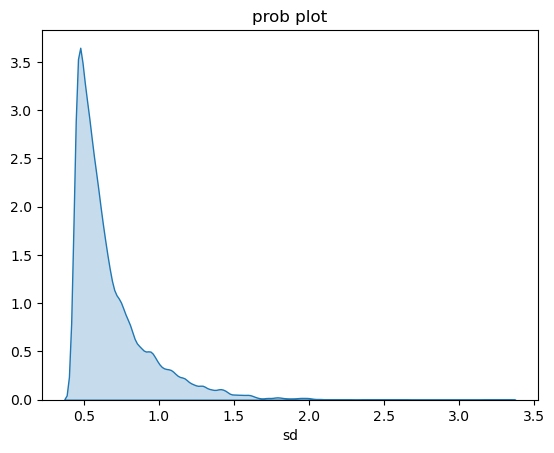

In [371]:
#calculate variance  and mean on vsd
import matplotlib.pyplot as plt
import seaborn as sns
data_ = data.loc[not_empty, ]
data_ = data_.groupby(data_.index).mean()
varianze = data_.std(axis=1)
medie=data_.mean(axis=1)
varianze_df = pd.DataFrame({'mean':medie,'sd':varianze})
varianze_sel = varianze_df[varianze_df["sd"] >varianze_df["sd"].median()]
sns.kdeplot(varianze_sel["sd"], fill=True, bw_adjust=0.5, common_norm=True)
plt.xlabel('sd')
plt.ylabel('')
plt.title('prob plot')
plt.show()
#varianze_df=varianze_df.drop(columns=['mean'])

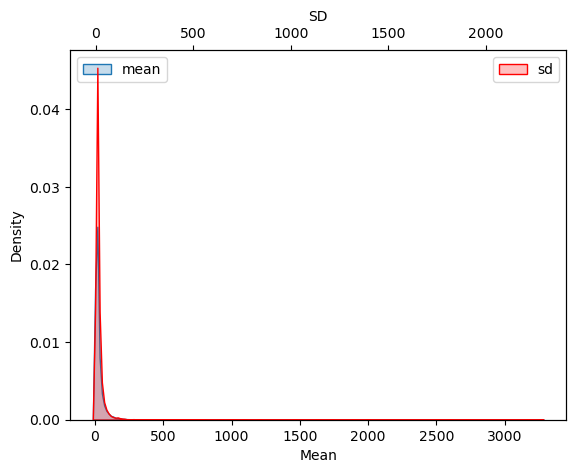

In [372]:
#calculate mean on fpkm
import matplotlib.pyplot as plt
import seaborn as sns
fpkm_ = data_f.loc[not_empty, ]
fpkm= fpkm.groupby(fpkm.index).mean()
medie = fpkm_.mean(axis=1)
sd=fpkm_.std(axis=1)
medie_df = pd.DataFrame({'mean':medie,'sd':sd})
medie_sel = medie_df[medie_df["mean"] >medie_df["mean"].median()]
fig, ax1 = plt.subplots()


sns.kdeplot(medie_sel["mean"], fill=True, bw_adjust=0.5, common_norm=False, label='mean', ax=ax1)
ax1.set_xlabel("Mean")
ax1.set_ylabel("Density")


ax2 = ax1.twiny()  # Aggiunge un altro asse x sopra
sns.kdeplot(medie_sel["sd"], fill=True, bw_adjust=0.5, common_norm=False, label='sd', ax=ax2, color='red')
ax2.set_xlabel("SD") 


ax1.legend(loc="upper left")
ax2.legend(loc="upper right")


plt.show()

In [373]:
varianze=varianze_df.rename(columns={'sd':'sd_vsd','mean':'mean_vsd'})

In [374]:
varianze.head()

,mean_vsd,sd_vsd
A1BG,6.621908,0.307189
A1CF,9.600383,0.874399
A2M,6.783986,0.705701
A2ML1,6.744526,0.765585
A3GALT2,6.464386,0.110609


In [375]:
fpkm_ = data_f.loc[not_empty, ]
medie = fpkm_.mean(axis=1)
sd=fpkm_.std(axis=1)
medie_df = pd.DataFrame({'mean':medie,'sd':sd})
medie_df['cv']=medie_df['sd']/medie_df['mean']
medie_df= medie_df.join(varianze, how='inner')
medie_df['cv_vsd']=medie_df['sd_vsd']/medie_df['mean_vsd']
#plt.scatter(x=medie_df['mean'],y=medie_df['sd'],c=medie_df['cv'],s=0.8)
#plt.colorbar()
medie_df=medie_df[medie_df['mean_vsd']>(medie_df['mean_vsd'].median()-medie_df['mean_vsd'].std())]
medie_df=medie_df[medie_df['sd_vsd']>(medie_df['sd_vsd'].median()-medie_df['sd_vsd'].std())]
medie_df=medie_df[medie_df['cv_vsd']>(medie_df['cv_vsd'].median()-medie_df['cv_vsd'].std())]
medie_df['gene']=medie_df.index
medie_df=medie_df.reset_index()
medie_df=medie_df.drop(columns=['index'])
medie_df=medie_df.sort_values('sd_vsd',ascending=False)
medie_df=medie_df.reset_index()
medie_df=medie_df.drop(columns=['index'])


In [376]:
corr_=medie_df.corr(method='spearman')
print(corr_)

              mean        sd        cv  mean_vsd    sd_vsd    cv_vsd
mean      1.000000  0.902473 -0.532200  0.890042  0.135560 -0.238822
sd        0.902473  1.000000 -0.177125  0.712144  0.442396  0.107501
cv       -0.532200 -0.177125  1.000000 -0.650648  0.585313  0.832472
mean_vsd  0.890042  0.712144 -0.650648  1.000000  0.073290 -0.333785
sd_vsd    0.135560  0.442396  0.585313  0.073290  1.000000  0.895390
cv_vsd   -0.238822  0.107501  0.832472 -0.333785  0.895390  1.000000


/tmp/ipykernel_607526/3932121475.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_=medie_df.corr(method='spearman')


In [377]:
medie_df

,mean,sd,cv,mean_vsd,sd_vsd,cv_vsd,gene
0,274.980371,688.848442,2.505082,10.536765,3.312279,0.314354,OLFM4
1,154.426277,453.120945,2.934222,9.186241,3.240628,0.352770,PIGR
2,60.086495,148.556954,2.472385,8.328321,3.201962,0.384467,IGF2
3,247.258552,757.020115,3.061654,9.137444,2.617593,0.286469,CST1
4,37.214763,49.112494,1.319705,9.772337,2.589574,0.264990,DUSP27
...,...,...,...,...,...,...,...
13381,0.136721,0.154342,1.128885,6.716440,0.223676,0.033303,HVCN1
13382,0.327469,0.522888,1.596757,6.757657,0.223572,0.033084,SERHL2
13383,0.104912,0.137298,1.308697,6.711593,0.223398,0.033285,CAPN3
13384,0.266061,0.168898,0.634809,7.114775,0.222893,0.031328,DUSP19


In [378]:
medie_df[medie_df['gene']=='']

,mean,sd,cv,mean_vsd,sd_vsd,cv_vsd,gene


In [379]:
#medie_df.drop(columns=['index'],inplace=True)
medie_df.drop(columns=['gene']).corr(method='spearman')

,mean,sd,cv,mean_vsd,sd_vsd,cv_vsd
mean,1.000000,0.902473,-0.532200,0.890042,0.135560,-0.238822
sd,0.902473,1.000000,-0.177125,0.712144,0.442396,0.107501
cv,-0.532200,-0.177125,1.000000,-0.650648,0.585313,0.832472
mean_vsd,0.890042,0.712144,-0.650648,1.000000,0.073290,-0.333785
sd_vsd,0.135560,0.442396,0.585313,0.073290,1.000000,0.895390
cv_vsd,-0.238822,0.107501,0.832472,-0.333785,0.895390,1.000000


<AxesSubplot: xlabel='mean_vsd', ylabel='sd_vsd'>

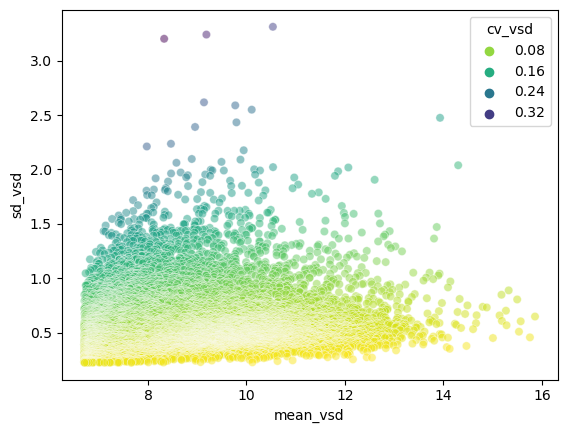

In [380]:
sns.scatterplot(data=medie_df,x='mean_vsd',y='sd_vsd',hue='cv_vsd',alpha=0.5,palette='viridis_r')
#plt.colorbar(label='cv_vsd')

In [381]:
selected_genes=medie_df.loc[:5999,'gene']

,mean,sd,cv,mean_vsd,sd_vsd,cv_vsd,gene
3372,41.607988,23.330243,0.560715,10.189455,0.64383,0.063186,HES1


In [383]:
file_name = "gene_list_6000_maxrepliche.txt"


with open(file_name, "w") as f:
    for gene in selected_genes:
        f.write(gene + "\n")

f.close()
file_name

'gene_list_6000_maxrepliche.txt'

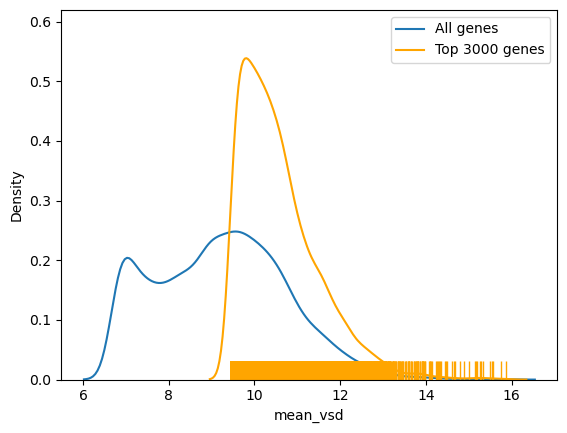

In [384]:
import seaborn as sns
import matplotlib.pyplot as plt


top_3000 = medie_df.nlargest(6000, 'mean_vsd')

sns.kdeplot(medie_df['mean_vsd'], label='All genes')


sns.kdeplot(top_3000['mean_vsd'], label='Top 3000 genes', color='orange')


sns.rugplot(top_3000['mean_vsd'], color='orange', height=0.05)


plt.legend()
plt.xlabel('mean_vsd')
plt.ylabel('Density')
plt.show()


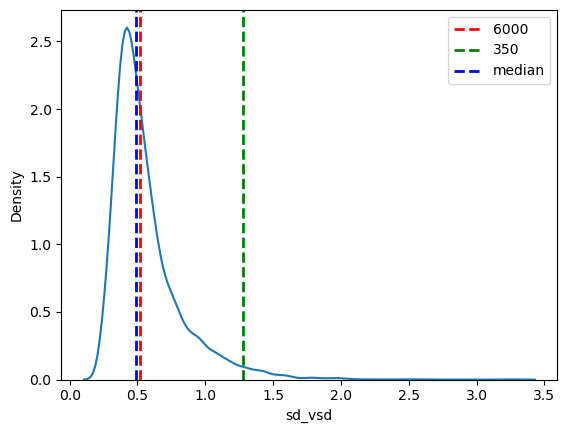

In [385]:
sns.kdeplot(medie_df['sd_vsd'])
plt.axvline(x=medie_df.loc[6000,'sd_vsd'], color='red', linestyle='--', linewidth=2,label='6000')
plt.axvline(x=medie_df.loc[350,'sd_vsd'], color='green', linestyle='--', linewidth=2,label='350')
plt.axvline(x=medie_df['sd_vsd'].median(), color='blue', linestyle='--', linewidth=2,label='median')
plt.legend()


In [386]:
a=data_f.loc[selected_genes,]
corr=a.T.corr(method='spearman')

In [387]:
print(len(selected_genes))  
print(len(set(selected_genes)))  

print(len(set(selected_genes) & set(data_.index)))  # Quanti sono realmente presenti
print(len(set(selected_genes) - set(data_.index)))  # Quanti non sono trovati

print(a.shape)  # Controlla la dimensione finale di a
print(a.isna().sum().sum())  # Se ci sono NaN, allora hai aggiunto geni inesistenti


6000
6000
6000
0
(6000, 132)
0


In [388]:
th=0.67
corr[(corr > -th) & (corr < th)] = 0
corr[(corr==1)]=0
corr[(corr>th) | (corr<-th)]=1

In [389]:
corr['ATOH1'].sort_values(ascending=False)


SPINK4       1.0
CLCA1        1.0
HEPACAM2     1.0
FCGBP        1.0
TPI1         0.0
            ... 
S100A10      0.0
FILIP1L      0.0
MMEL1        0.0
GPD1         0.0
UHRF1BP1L    0.0
Name: ATOH1, Length: 6000, dtype: float64

In [393]:
import pandas as pd
import networkx as nx

# Supponiamo che `corr` sia un DataFrame Pandas con i nomi dei geni come indice e colonne
gene_names = corr.index.tolist()

# Costruisci il grafo dalla matrice numpy, NON etichettato
G = nx.from_numpy_array(corr.to_numpy())

# Rinomina i nodi del grafo con i nomi dei geni
mapping = {i: gene_names[i] for i in range(len(gene_names))}
G = nx.relabel_nodes(G, mapping)

# Rimuovi i nodi isolati
G.remove_nodes_from(list(nx.isolates(G)))

# Estrai gli archi
edge_list = list(G.edges())

# Salva in CSV
df_edges = pd.DataFrame(edge_list, columns=['source', 'target'])
df_edges.to_csv("edge_list_with_gene_names_0.67.csv", index=False)

print("Salvato come edge_list_with_gene_names_0.67.csv")

Salvato come edge_list_with_gene_names_0.67.csv


In [397]:
df_edges[(df_edges['source'] == 'ATOH1') | (df_edges['target'] == 'ATOH1')]

,source,target
95,FCGBP,ATOH1
103,CLCA1,ATOH1
409,SPINK4,ATOH1
624,ATOH1,HEPACAM2


In [398]:
import networkx as nx

G = nx.from_numpy_array(corr.to_numpy())

# Numero di nodi e archi
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# Grado dei nodi
degree_dict = dict(G.degree())

# Componenti connesse
num_components = nx.number_connected_components(G)
components = list(nx.connected_components(G))

# Diametro e raggio (se connesso)
if nx.is_connected(G):
    diameter = nx.diameter(G)
    radius = nx.radius(G)
else:
    diameter = radius = None  # Non definito per grafi non connessi

# Coefficiente di clustering medio
clustering_coefficient = nx.average_clustering(G)

# Centralità dei gradi
degree_centrality = nx.degree_centrality(G)

# Stampiamo i risultati
print(f"Numero di nodi: {num_nodes}")
print(f"Numero di archi: {num_edges}")
#print(f"Grado dei nodi: {degree_dict}")
print(f"Numero di componenti connesse: {num_components}")
#print(f"Componenti connesse: {components}")
if diameter is not None:
    print(f"Diametro: {diameter}")
    print(f"Raggio: {radius}")
print(f"Coefficiente di clustering medio: {clustering_coefficient}")
#print(f"Centralità dei gradi: {degree_centrality}")

Numero di nodi: 6000
Numero di archi: 4022
Numero di componenti connesse: 4730
Coefficiente di clustering medio: 0.0722789632286601


/tmp/ipykernel_607526/1618363400.py:20: RuntimeWarning: divide by zero encountered in log
  log_degrees = np.log(degrees)


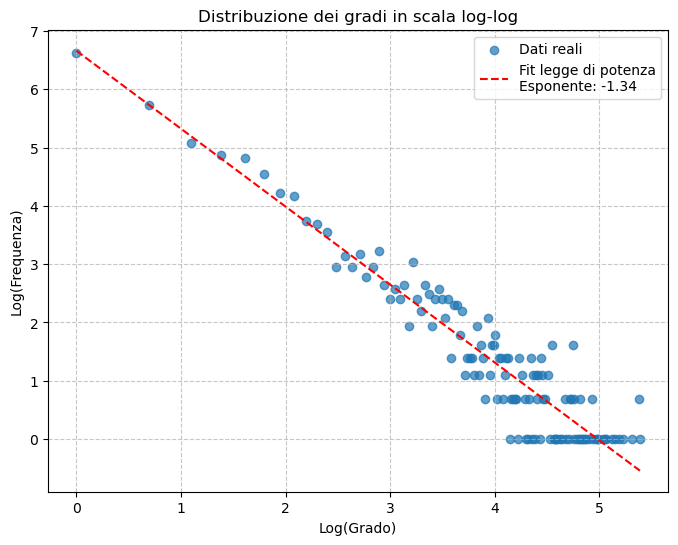

In [175]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Supponiamo che il grafo sia `G`
# Se il grafo è diretto, lo rendiamo non orientato per questa analisi
if G.is_directed():
    G = G.to_undirected()

# Calcola i gradi di tutti i nodi
degree_sequence = [d for n, d in G.degree()]

# Conta la frequenza di ogni grado unico
degree_counts = np.bincount(degree_sequence)
degrees = np.nonzero(degree_counts)[0]  # Prende solo i gradi presenti
counts = degree_counts[degrees]  # Prende solo le frequenze non nulle

# Converti in logaritmi per la regressione
log_degrees = np.log(degrees)
log_counts = np.log(counts)

# Rimuove valori infiniti (-inf per frequenze zero)
valid = ~np.isinf(log_degrees) & ~np.isinf(log_counts)
log_degrees = log_degrees[valid]
log_counts = log_counts[valid]

# Funzione di legge di potenza da adattare
def power_law(x, a, b):
    return a * x + b

# Fit lineare in scala log-log
params, _ = curve_fit(power_law, log_degrees, log_counts)

# Plot della distribuzione dei gradi in scala log-log
plt.figure(figsize=(8, 6))
plt.scatter(log_degrees, log_counts, label="Dati reali", alpha=0.7)
plt.plot(log_degrees, power_law(log_degrees, *params), color="r", linestyle="--", label=f"Fit legge di potenza\nEsponente: {params[0]:.2f}")

plt.xlabel("Log(Grado)")
plt.ylabel("Log(Frequenza)")
plt.title("Distribuzione dei gradi in scala log-log")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.7)
plt.show()


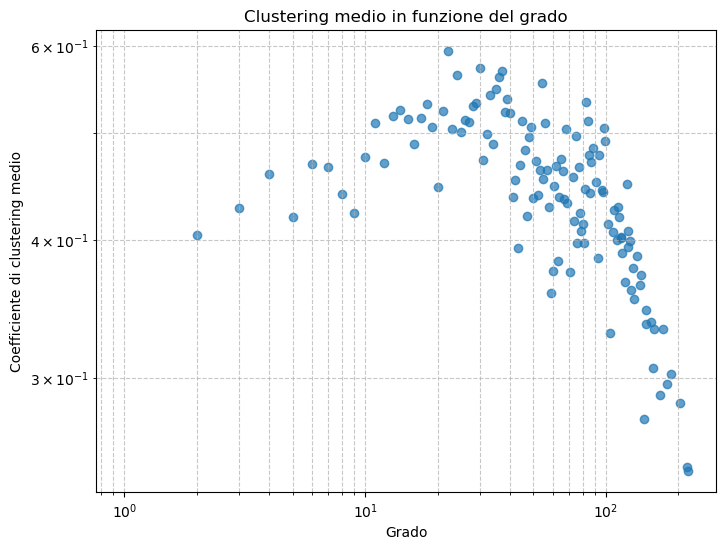

In [176]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Calcola il clustering di ogni nodo
clustering = nx.clustering(G)

# Raggruppa per grado
degree_to_clustering = {}
for node, deg in G.degree():
    if deg not in degree_to_clustering:
        degree_to_clustering[deg] = []
    degree_to_clustering[deg].append(clustering[node])

# Media del clustering per ciascun grado
degree_vals = np.array(list(degree_to_clustering.keys()))
clustering_vals = np.array([np.mean(vals) for vals in degree_to_clustering.values()])

# Ordina per grado crescente
sorted_indices = np.argsort(degree_vals)
degree_vals = degree_vals[sorted_indices]
clustering_vals = clustering_vals[sorted_indices]

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(degree_vals, clustering_vals, alpha=0.7)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Grado")
plt.ylabel("Coefficiente di clustering medio")
plt.title("Clustering medio in funzione del grado")
plt.grid(True, which="both", linestyle="--", alpha=0.7)
plt.show()


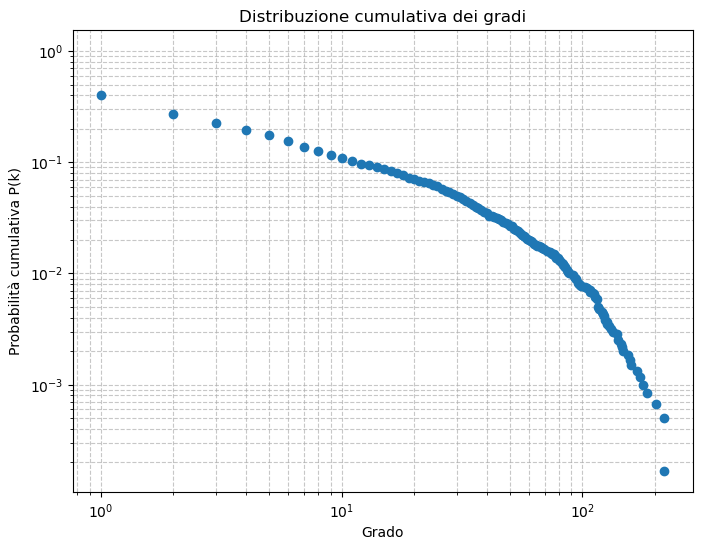

In [177]:
from collections import Counter

degree_sequence = [d for n, d in G.degree()]
degree_count = Counter(degree_sequence)
degrees, counts = zip(*sorted(degree_count.items()))

# Calcola la distribuzione cumulativa
cumulative_counts = np.cumsum(counts[::-1])[::-1]  # Somma cumulativa inversa

# Plot
plt.figure(figsize=(8, 6))
plt.plot(degrees, cumulative_counts / cumulative_counts[0], marker="o", linestyle="none")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Grado")
plt.ylabel("Probabilità cumulativa P(k)")
plt.title("Distribuzione cumulativa dei gradi")
plt.grid(True, which="both", linestyle="--", alpha=0.7)
plt.show()


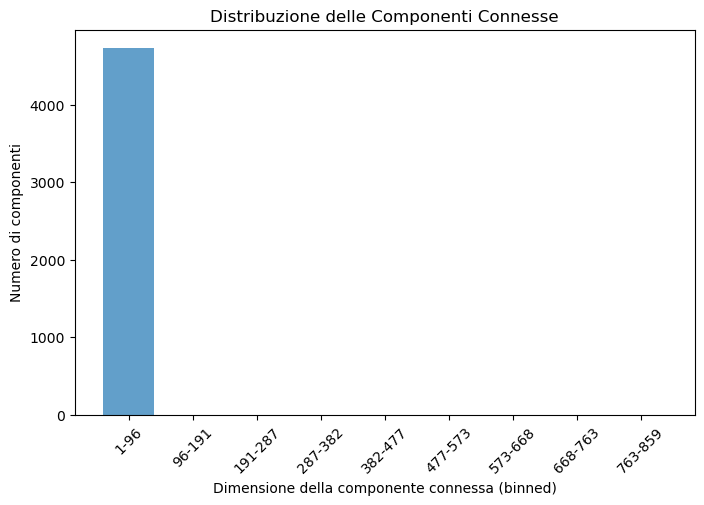

In [399]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

adj_matrix=corr.to_numpy()

# Creazione del grafo da NetworkX
G = nx.from_numpy_matrix(adj_matrix)

# Trova le componenti connesse
components = list(nx.connected_components(G))
component_sizes = [len(comp) for comp in components]

# Creazione di un istogramma binned della distribuzione delle componenti connesse
bin_edges = np.linspace(1, max(component_sizes), num=10, dtype=int)
bin_counts, _ = np.histogram(component_sizes, bins=bin_edges)

# Creazione di un DataFrame per visualizzazione
df = pd.DataFrame({
    "Bin Intervallo": [f"{bin_edges[i]}-{bin_edges[i+1]}" for i in range(len(bin_edges)-1)],
    "Numero Componenti": bin_counts
})




# Grafico della distribuzione delle componenti connesse
plt.figure(figsize=(8, 5))
plt.bar(df["Bin Intervallo"], df["Numero Componenti"], alpha=0.7)
plt.xlabel("Dimensione della componente connessa (binned)")
plt.ylabel("Numero di componenti")
plt.xticks(rotation=45)
plt.title("Distribuzione delle Componenti Connesse")
plt.show()

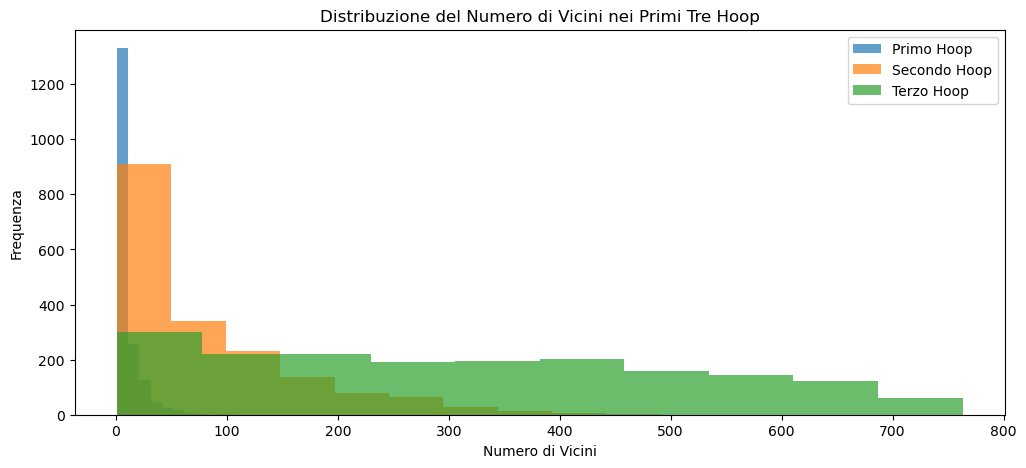

In [58]:

largest_component = max((comp for comp in components if len(comp) > 1), key=len)
G_largest = G.subgraph(largest_component)
hoop_counts = []
for node in G_largest.nodes():
    first_hoop = set(nx.single_source_shortest_path_length(G_largest, node, cutoff=1).keys()) - {node}
    second_hoop = set(nx.single_source_shortest_path_length(G_largest, node, cutoff=2).keys()) - first_hoop - {node}
    third_hoop = set(nx.single_source_shortest_path_length(G_largest, node, cutoff=3).keys()) - first_hoop - second_hoop - {node}

    hoop_counts.append({
        "Nodo": node,
        "Vicini Primo Hoop": len(first_hoop),
        "Vicini Secondo Hoop": len(second_hoop),
        "Vicini Terzo Hoop": len(third_hoop),
    })


df_hoops = pd.DataFrame(hoop_counts)

plt.figure(figsize=(12, 5))

plt.hist(df_hoops["Vicini Primo Hoop"], bins=10, alpha=0.7, label="Primo Hoop")
plt.hist(df_hoops["Vicini Secondo Hoop"], bins=10, alpha=0.7, label="Secondo Hoop")
plt.hist(df_hoops["Vicini Terzo Hoop"], bins=10, alpha=0.7, label="Terzo Hoop")

plt.xlabel("Numero di Vicini")
plt.ylabel("Frequenza")
plt.title("Distribuzione del Numero di Vicini nei Primi Tre Hoop")
plt.legend()
plt.show()

/usr/lib/python3/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


RecursionError: maximum recursion depth exceeded while calling a Python object

<Figure size 1000x800 with 0 Axes>

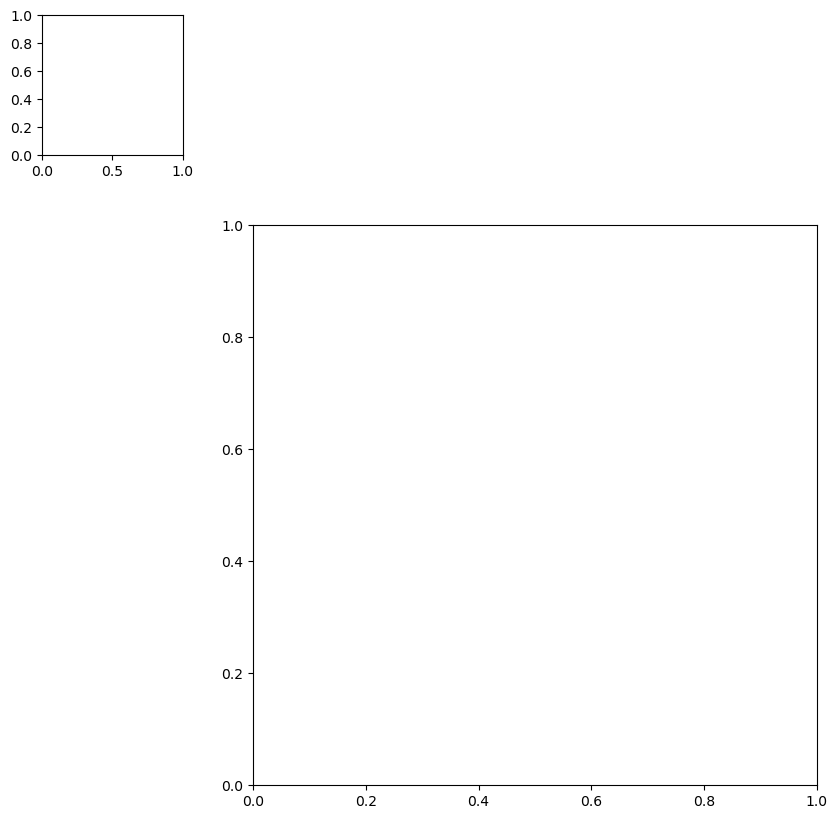

In [130]:
import matplotlib.colors as mcolors
plt.figure(figsize=(10, 8))  # Dimensioni della figura
cmap = mcolors.LinearSegmentedColormap.from_list("red_white_blue", ["blue", "white", "red"])
sns.clustermap(
    corr, 
    cmap=cmap,  
    vmin=-1, vmax=1, 
    center=0  
)

plt.show()

In [248]:
component_sizes

[1,
 1,
 1,
 1,
 1913,
 1,
 1,
 1,
 7,
 1,
 1,
 3,
 4,
 1,
 1,
 1,
 4,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 2,
 1,
 2,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 6,
 1,
 3,
 9,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 1,
 2,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 3,
 1,
 1,
 1,
 1,
 3,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 4,
 1,
 3,
 1,
 1,
 1,
 1,
 2,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 3,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 10,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 6,
 1,
 1,
 3,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 4,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,


In [400]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# Numero medio di archi per nodo
average_degree = (2 * num_edges) / num_nodes if num_nodes > 0 else 0

print(f"Average number of edges per node: {average_degree:.2f}")
print(f"Numero nodi prima: {G.number_of_nodes()}")
print(f"Numero archi prima: {G.number_of_edges()}")

isolated = list(nx.isolates(G))
G.remove_nodes_from(isolated)

print(f"Numero nodi dopo: {G.number_of_nodes()}")
print(f"Numero archi dopo: {G.number_of_edges()}")
import pandas as pd


edges = list(G.edges(data=True))

# Converti in DataFrame
# df_edges = pd.DataFrame([
#     (u, v, d.get('weight', 1)) for u, v, d in edges
# ], columns=['source', 'target', 'weight'])

# # Salva in CSV
#df_edges.to_csv("grafo_edges.csv", index=False)

Average number of edges per node: 1.34
Numero nodi prima: 6000
Numero archi prima: 4022
Numero nodi dopo: 1453
Numero archi dopo: 4022


In [256]:
edges

[(4, 147, {'weight': 1.0}),
 (4, 302, {'weight': 1.0}),
 (5, 118, {'weight': 1.0}),
 (5, 1082, {'weight': 1.0}),
 (6, 11, {'weight': 1.0}),
 (6, 146, {'weight': 1.0}),
 (6, 157, {'weight': 1.0}),
 (6, 408, {'weight': 1.0}),
 (6, 650, {'weight': 1.0}),
 (6, 1024, {'weight': 1.0}),
 (6, 1093, {'weight': 1.0}),
 (6, 1378, {'weight': 1.0}),
 (6, 3197, {'weight': 1.0}),
 (10, 125, {'weight': 1.0}),
 (10, 128, {'weight': 1.0}),
 (10, 369, {'weight': 1.0}),
 (10, 669, {'weight': 1.0}),
 (10, 986, {'weight': 1.0}),
 (10, 4769, {'weight': 1.0}),
 (11, 20, {'weight': 1.0}),
 (11, 146, {'weight': 1.0}),
 (11, 157, {'weight': 1.0}),
 (11, 251, {'weight': 1.0}),
 (11, 408, {'weight': 1.0}),
 (11, 650, {'weight': 1.0}),
 (11, 918, {'weight': 1.0}),
 (11, 1024, {'weight': 1.0}),
 (11, 1378, {'weight': 1.0}),
 (11, 2372, {'weight': 1.0}),
 (11, 3309, {'weight': 1.0}),
 (14, 404, {'weight': 1.0}),
 (14, 922, {'weight': 1.0}),
 (15, 67, {'weight': 1.0}),
 (15, 4942, {'weight': 1.0}),
 (16, 158, {'weight

In [251]:
edges

[(4, 147, {'weight': 1.0}),
 (4, 302, {'weight': 1.0}),
 (5, 118, {'weight': 1.0}),
 (5, 1082, {'weight': 1.0}),
 (6, 11, {'weight': 1.0}),
 (6, 146, {'weight': 1.0}),
 (6, 157, {'weight': 1.0}),
 (6, 408, {'weight': 1.0}),
 (6, 650, {'weight': 1.0}),
 (6, 1024, {'weight': 1.0}),
 (6, 1093, {'weight': 1.0}),
 (6, 1378, {'weight': 1.0}),
 (6, 3197, {'weight': 1.0}),
 (10, 125, {'weight': 1.0}),
 (10, 128, {'weight': 1.0}),
 (10, 369, {'weight': 1.0}),
 (10, 669, {'weight': 1.0}),
 (10, 986, {'weight': 1.0}),
 (10, 4769, {'weight': 1.0}),
 (11, 20, {'weight': 1.0}),
 (11, 146, {'weight': 1.0}),
 (11, 157, {'weight': 1.0}),
 (11, 251, {'weight': 1.0}),
 (11, 408, {'weight': 1.0}),
 (11, 650, {'weight': 1.0}),
 (11, 918, {'weight': 1.0}),
 (11, 1024, {'weight': 1.0}),
 (11, 1378, {'weight': 1.0}),
 (11, 2372, {'weight': 1.0}),
 (11, 3309, {'weight': 1.0}),
 (14, 404, {'weight': 1.0}),
 (14, 922, {'weight': 1.0}),
 (15, 67, {'weight': 1.0}),
 (15, 4942, {'weight': 1.0}),
 (16, 158, {'weight

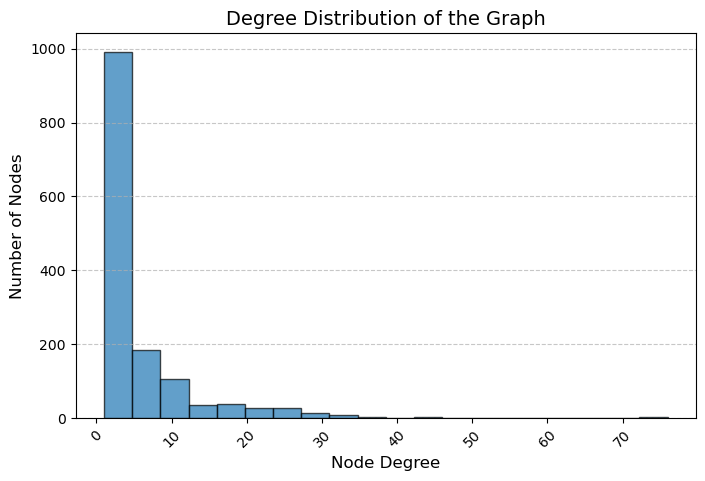

In [401]:
degrees = [G.degree(n) for n in G.nodes()]

# Imposta il numero di bin per migliorare la leggibilità
num_bins = min(20, max(degrees) - min(degrees) + 1)  # Limita il numero di bin

plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=num_bins, edgecolor="black", alpha=0.7)

# Miglioramenti agli assi
plt.xlabel("Node Degree", fontsize=12)
plt.ylabel("Number of Nodes", fontsize=12)
plt.title("Degree Distribution of the Graph", fontsize=14)

# Migliora la leggibilità dell'asse x
plt.xticks(rotation=45)  # Ruota le etichette per renderle leggibili
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Aggiunge griglia per migliore lettura

plt.show()

In [137]:
import pandas as pd

# Crea una lista di tuple dagli archi
edges = list(G.edges(data=True))

# Converti in DataFrame
df_edges = pd.DataFrame([
    (u, v, d.get('weight', 1)) for u, v, d in edges
], columns=['source', 'target', 'weight'])

# Salva in CSV
df_edges.to_csv("grafo_edges.csv", index=False)

In [26]:
#run GENIE3
mat_=a.T
gene_names=list(mat_.columns)


In [ ]:
print("Running GENIE3...")

VIM = GENIE3(mat_.to_numpy(), gene_names)


link_list = get_link_list(VIM, gene_names=gene_names)


df_links = pd.DataFrame(link_list, columns=["Regulator", "Target", "Importance"])


